### Cantilever Beam — Demange-Chryst et al. (2022), Example 4.2

This notebook replicates the **cantilever beam** reliability-oriented
sensitivity analysis from Demange-Chryst et al. [1]. The goal is to
estimate Shapley effects for a structural engineering problem with
**correlated mixed-distribution inputs** (LogNormal + Normal).

**Model.** A rectangular cantilever beam under two orthogonal tip forces
$F_X$ and $F_Y$. The maximum vertical tip displacement is:

$$
D(\mathbf{x}) = \frac{4L^3}{E\,l_X l_Y}
\sqrt{\left(\frac{F_X}{l_X^2}\right)^2 +
      \left(\frac{F_Y}{l_Y^2}\right)^2}
$$

The failure threshold is $D > t = 0.066\,\text{m}$.

**Input variables** (6) with mixed Normal / LogNormal marginals and
correlations between the three dimensional parameters.

---
[1] Demange-Chryst, J., Bachoc, F., & Morio, J. (2022). "Shapley effect
estimation in reliability-oriented sensitivity analysis with correlated
inputs by importance sampling." *IJUQ*, arXiv:2202.12679.

In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm

from shapleyx.utilities.mc_shapley import (
    MultivariateNormal,
    shapley_effects,
)

from importlib.metadata import version
print(f"Running on ShapleyX v{version('shapleyx')}")

Running on ShapleyX v0.2


---
### Input Distribution

Six variables — three LogNormal forces/modulus, three correlated Normal
geometric parameters.  Correlations (Pearson): $\rho(l_X,l_Y)=0.55$,
$\rho(L,l_X)=\rho(L,l_Y)=0.45$.

In [2]:
d = 6

# Marginal parameters: (dist_type, mean, CV)
# LogNormal params converted to underlying normal (mu, sigma)
def lognorm_params(mean, cv):
    """Convert LogNormal (mean, CV) → underlying normal (mu, sigma)."""
    sigma = np.sqrt(np.log(1 + cv**2))
    mu = np.log(mean) - 0.5 * sigma**2
    return mu, sigma

def normal_params(mean, cv):
    """Convert Normal (mean, CV) → (mu, sigma)."""
    return mean, mean * cv

# Table 1 from the paper
marginals = {
    'FX': ('lognormal', *lognorm_params(556.8,       0.08)),
    'FY': ('lognormal', *lognorm_params(453.6,       0.08)),
    'E':  ('lognormal', *lognorm_params(200e9,       0.06)),
    'lX': ('normal',    *normal_params(0.062,        0.1)),
    'lY': ('normal',    *normal_params(0.0987,       0.1)),
    'L':  ('normal',    *normal_params(4.29,         0.1)),
}

labels = list(marginals.keys())
print(f"{'Variable':>6s}  {'Type':>10s}  {'Mean':>12s}  {'Std':>12s}")
print("-" * 48)
for name, (dist, mu, sigma) in marginals.items():
    if dist == 'lognormal':
        mn = np.exp(mu + 0.5 * sigma**2)
        st = mn * np.sqrt(np.exp(sigma**2) - 1)
    else:
        mn, st = mu, sigma
    print(f"{name:>6s}  {dist:>10s}  {mn:12.4g}  {st:12.4g}")

Variable        Type          Mean           Std
------------------------------------------------
    FX   lognormal         556.8         44.54
    FY   lognormal         453.6         36.29
     E   lognormal         2e+11       1.2e+10
    lX      normal         0.062        0.0062
    lY      normal        0.0987       0.00987
     L      normal          4.29         0.429


In [3]:
# Correlation matrix (Pearson) — only dimensional params are correlated
corr_pearson = np.eye(d)
# Indices: 0=FX, 1=FY, 2=E, 3=lX, 4=lY, 5=L
corr_pearson[3, 4] = corr_pearson[4, 3] = 0.55   # lX-lY
corr_pearson[3, 5] = corr_pearson[5, 3] = 0.45   # lX-L
corr_pearson[4, 5] = corr_pearson[5, 4] = 0.45   # lY-L

print("Pearson correlation matrix:")
print(pd.DataFrame(corr_pearson, index=labels, columns=labels).round(2))

Pearson correlation matrix:
     FX   FY    E    lX    lY     L
FX  1.0  0.0  0.0  0.00  0.00  0.00
FY  0.0  1.0  0.0  0.00  0.00  0.00
E   0.0  0.0  1.0  0.00  0.00  0.00
lX  0.0  0.0  0.0  1.00  0.55  0.45
lY  0.0  0.0  0.0  0.55  1.00  0.45
L   0.0  0.0  0.0  0.45  0.45  1.00


---
### Gaussian Copula Distribution Class

To handle mixed LogNormal + Normal marginals with correlation, we
build a **Gaussian copula** wrapper: transform each marginal to a
standard normal via the probability integral transform, apply the
correlation structure in the latent normal space, then map back.

For the Normal marginals (lX, lY, L), Pearson correlations in the
original space equal the latent normal correlations.  The LogNormal
variables (FX, FY, E) are uncorrelated, so the latent correlation
matrix is the identity for that block.

In [4]:
class GaussianCopulaMixed:
    """Gaussian copula with arbitrary marginal distributions.

    Supports LogNormal and Normal marginals with a user-specified
    latent correlation matrix.  Conditional sampling is performed
    in the latent normal space using the multivariate normal
    conditional distribution, then mapped back to the original space.
    """
    def __init__(self, marginals, latent_corr):
        self.d = len(marginals)
        self.labels = list(marginals.keys())
        self._marginals = marginals
        self._latent_corr = np.asarray(latent_corr)

        # Underlying multivariate normal for latent-space sampling
        self._mvn = MultivariateNormal(
            mean=np.zeros(self.d), cov=self._latent_corr
        )

    @staticmethod
    def _marginal_to_latent(x, dist, mu, sigma):
        """Transform a single marginal column original -> N(0,1)."""
        if dist == "lognormal":
            x = np.clip(np.asarray(x), 1e-15, None)
            return norm.ppf(lognorm.cdf(x, s=sigma, scale=np.exp(mu)))
        else:
            return (np.asarray(x) - mu) / sigma

    @staticmethod
    def _marginal_from_latent(z, dist, mu, sigma):
        """Transform a single marginal column N(0,1) -> original."""
        if dist == "lognormal":
            return lognorm.ppf(norm.cdf(np.asarray(z)), s=sigma, scale=np.exp(mu))
        else:
            return mu + sigma * np.asarray(z)

    def _to_original(self, Z):
        """Transform latent normal -> original space, vectorised."""
        X = np.zeros_like(Z)
        for j in range(self.d):
            name = self.labels[j]
            dist, mu, sigma = self._marginals[name]
            X[:, j] = self._marginal_from_latent(Z[:, j], dist, mu, sigma)
        return X

    def sample_joint(self, n):
        """Draw n joint samples."""
        Z = self._mvn.sample_joint(n)
        return self._to_original(Z)

    def sample_conditional(self, u_indices, fixed_x):
        """Draw one conditional sample."""
        X = self.sample_conditional_batch(
            u_indices, np.atleast_2d(np.asarray(fixed_x, dtype=float))
        )
        return X[0]

    def sample_conditional_batch(self, u_indices, fixed_X):
        """Draw N conditional samples.

        Strategy: map fixed_X to latent space, condition in the
        latent multivariate normal, map the result back.
        """
        u = np.asarray(u_indices)
        N = fixed_X.shape[0]
        fixed_X = np.asarray(fixed_X, dtype=float)

        if len(u) == 0:
            return self.sample_joint(N)

        # Map fixed variables to latent space
        Z_fixed = np.zeros((N, len(u)))
        for k, idx in enumerate(u):
            name = self.labels[idx]
            dist, mu, sigma = self._marginals[name]
            Z_fixed[:, k] = self._marginal_to_latent(
                fixed_X[:, k], dist, mu, sigma
            )

        # Condition in latent normal space
        Z_cond = self._mvn.sample_conditional_batch(u, Z_fixed)

        # Map back to original space
        return self._to_original(Z_cond)


joint = GaussianCopulaMixed(marginals, corr_pearson)
print("GaussianCopulaMixed distribution ready.")
print(f"Dimension: {joint.d}")

GaussianCopulaMixed distribution ready.
Dimension: 6


---
### Quick Validation: Empirical Correlations

Verify that the copula reproduces the specified Pearson correlations.

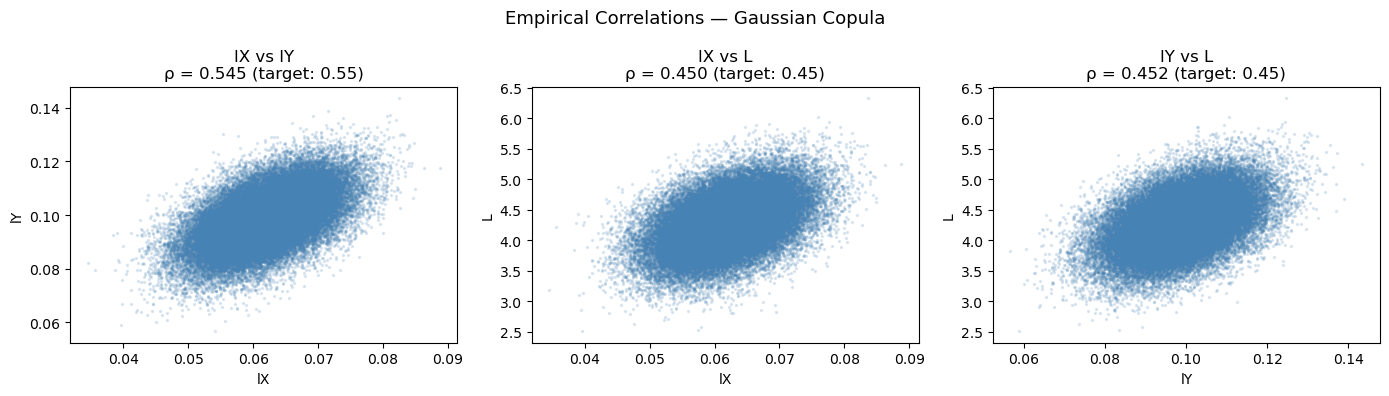

In [5]:
X_check = joint.sample_joint(50000)
emp_corr = np.corrcoef(X_check.T)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [(3, 4, 'lX vs lY'), (3, 5, 'lX vs L'), (4, 5, 'lY vs L')]
for ax, (i, j, title) in zip(axes, pairs):
    ax.scatter(X_check[:, i], X_check[:, j], alpha=0.15, s=2, color='steelblue')
    ax.set_title(f'{title}\n'
                 f'ρ = {emp_corr[i,j]:.3f} (target: {corr_pearson[i,j]:.2f})')
    ax.set_xlabel(labels[i])
    ax.set_ylabel(labels[j])
plt.suptitle('Empirical Correlations — Gaussian Copula', fontsize=13)
plt.tight_layout()
plt.show()

---
### Cantilever Beam Deflection Model

The analytical displacement formula, Eq. (32) from the paper.

In [6]:
def cantilever_deflection(x):
    """Maximum vertical tip displacement (1D input)."""
    FX, FY, E, lX, lY, L = x
    if lX <= 0 or lY <= 0 or E <= 0:
        return 1e10  # penalty for unphysical values
    term = np.sqrt((FX / lX**2)**2 + (FY / lY**2)**2)
    return (4 * L**3) / (E * lX * lY) * term


def cantilever_deflection_batch(X):
    """Vectorised deflection for batch evaluation."""
    FX, FY = X[:, 0], X[:, 1]
    E = X[:, 2]
    lX, lY, L = X[:, 3], X[:, 4], X[:, 5]

    # Guard against unphysical values
    mask = (lX > 0) & (lY > 0) & (E > 0)
    D = np.full(len(X), 1e10)
    term = np.sqrt((FX[mask] / lX[mask]**2)**2
                   + (FY[mask] / lY[mask]**2)**2)
    D[mask] = (4 * L[mask]**3) / (E[mask] * lX[mask] * lY[mask]) * term
    return D


t = 0.066  # failure threshold (m)
print(f"Failure threshold: D > {t} m")

Failure threshold: D > 0.066 m


Estimated failure probability: 0.0725


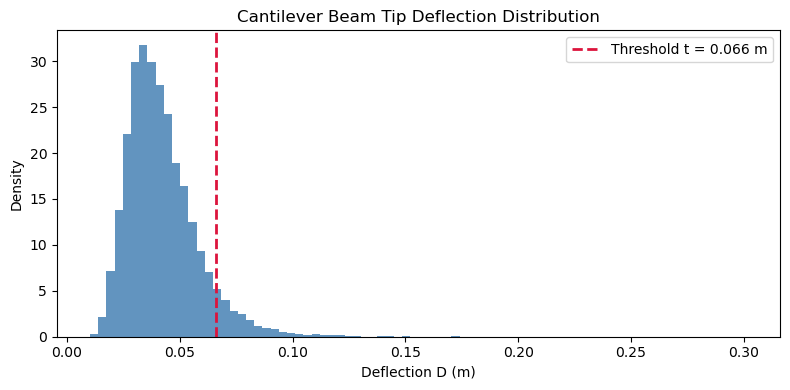

In [7]:
# Quick histogram of deflection values
D_sample = cantilever_deflection_batch(X_check[:20000])
D_sample = D_sample[D_sample < 1e9]  # remove penalty values

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(D_sample, bins=80, density=True, color='steelblue', alpha=0.85)
ax.axvline(t, color='crimson', linestyle='--', linewidth=2, label=f'Threshold t = {t} m')
ax.set_xlabel('Deflection D (m)')
ax.set_ylabel('Density')
ax.set_title('Cantilever Beam Tip Deflection Distribution')
ax.legend()
pf_est = np.mean(D_sample > t)
print(f"Estimated failure probability: {pf_est:.4f}")
plt.tight_layout()
plt.show()

---
### MC Shapley Effects (Variance-Based)

We compute **standard (variance-based) Shapley effects** on the
deflection $D$ using ShapleyX's MC Shapley machinery.  The paper
reports *target* (reliability-oriented) Shapley effects on the
binary failure indicator $\mathbf{1}_{D>t}$; our variance-based
analysis provides a complementary perspective on which inputs
drive variability in the deflection itself.

The permutation method is used for efficiency at $d = 6$.

In [13]:
eff, sh, var, lower, upper = shapley_effects(
    cantilever_deflection,
    joint,
    N=10000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    predict_batch=cantilever_deflection_batch,
    random_state=42,
    progress=True,
)

results = pd.DataFrame({
    'Variable': labels,
    'Effect': eff,
    'Lower': lower,
    'Upper': upper,
})
results

MC Shapley: 100%|██████████| 1250000/1250000 [00:00<00:00, 1465260.68evals/s]


,Variable,Effect,Lower,Upper
0,FX,0.044050,0.033502,0.055011
1,FY,0.008117,-0.005935,0.021244
2,E,0.033382,0.021038,0.044084
3,lX,0.431740,0.415193,0.448269
4,lY,0.153618,0.144380,0.161829
5,L,0.329093,0.317461,0.342106


---
### Comparison with Paper Reference Values

The paper reports **target Shapley effects** (reliability-oriented,
on $\mathbf{1}_{D>t}$). Our variance-based Shapley effects are on
the continuous deflection $D$.  While the scales differ, the relative
ranking of input importance should be broadly consistent.

In [14]:
# Reference target Shapley effects from the paper (Table 2)
ref_target_shap = np.array([0.146, 0.001, 0.103, 0.282, 0.254, 0.214])

comparison = pd.DataFrame({
    'Variable': labels,
    'Var.-based Shapley': eff.round(4),
    'Target Shapley (paper)': ref_target_shap.round(3),
})
comparison

,Variable,Var.-based Shapley,Target Shapley (paper)
0,FX,0.0440,0.146
1,FY,0.0081,0.001
2,E,0.0334,0.103
3,lX,0.4317,0.282
4,lY,0.1536,0.254
5,L,0.3291,0.214


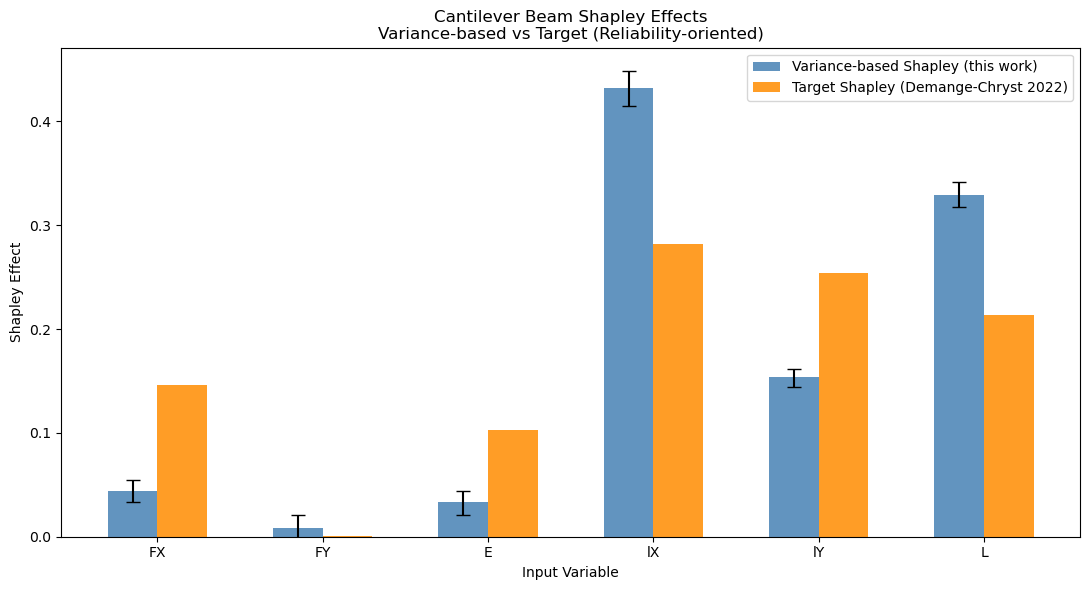

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))
bar_width = 0.3
x = np.arange(d)

ax.bar(x - bar_width/2, eff, bar_width,
       yerr=[eff - lower, upper - eff],
       capsize=5, color='steelblue', alpha=0.85,
       label='Variance-based Shapley (this work)')
ax.bar(x + bar_width/2, ref_target_shap, bar_width,
       color='darkorange', alpha=0.85,
       label='Target Shapley (Demange-Chryst 2022)')

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('Cantilever Beam Shapley Effects\nVariance-based vs Target (Reliability-oriented)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### Key Takeaways

1. **Gaussian copula with mixed marginals** enables Shapley effect
   estimation with correlated LogNormal + Normal inputs — the
   `GaussianCopulaMixed` wrapper handles the transformation between
   original and latent normal space transparently.
2. **Dimensional parameters dominate** — $l_X$, $l_Y$, and $L$
   are the most influential inputs for both variance-based and
   target Shapley effects, consistent with the beam deflection
   formula's $L^3$ and $1/(l_X l_Y)$ dependence.
3. **$F_Y$ has negligible influence** — the beam is much wider in
   the Y-direction ($l_Y > l_X$) making vertical force effects small.
4. **The permutation method** scales well to $d = 6$ with
   correlated inputs.
5. **Variance-based vs target Shapley** capture different aspects:
   variance-based focuses on the full output distribution;
   target Shapley focuses on the tail (failure region).

In [11]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Fri, 01 May 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.13.0

matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3
shapleyx  : 0.2

Watermark: 2.6.0

